In [2]:
# Cell 1: Train the Final Production Model
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import re
import time

print("--- Step 1: Initializing Final Production Model ---")

# 1. Load Data
df = pd.read_csv('application_train_fully_preprocessed.csv')
df = df.rename(columns = lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

X = df.drop(columns=['TARGET'])
y = df['TARGET']

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Train the Winning Baseline Model
final_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    is_unbalance=True, # The winning configuration
    random_state=42,
    n_jobs=-1
)

print("Training Master Model...")
start_time = time.time()
final_model.fit(X_train, y_train)
print(f"Training Complete! Time elapsed: {time.time() - start_time:.2f} seconds.")

--- Step 1: Initializing Final Production Model ---
Training Master Model...
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 153
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Training Complete! Time elapsed: 5.54 seconds.


--- Final Evaluation (Threshold: 0.58) ---
AUC-ROC Score: 0.7111

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88     56538
           1       0.18      0.45      0.26      4965

    accuracy                           0.79     61503
   macro avg       0.56      0.64      0.57     61503
weighted avg       0.88      0.79      0.83     61503



c:\neww\FYP\microloan-credit-scoring\backend\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


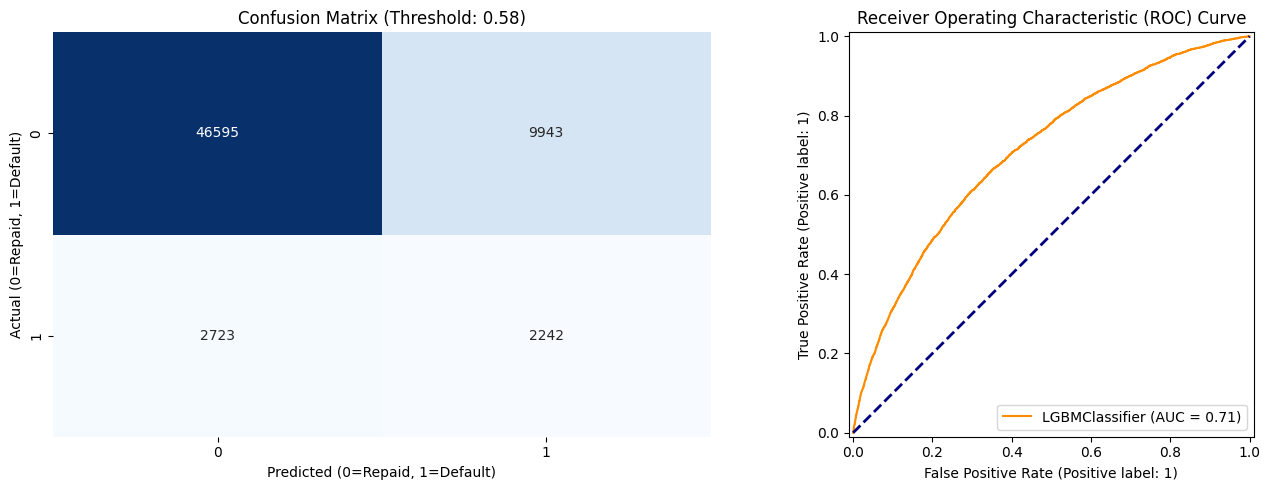

In [3]:
# Cell 2: Comprehensive Evaluation using Optimal Threshold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Predict Probabilities
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# 2. APPLY THE CUSTOM OPTIMAL THRESHOLD (0.58)
OPTIMAL_THRESHOLD = 0.58
y_pred_final = (y_pred_proba >= OPTIMAL_THRESHOLD).astype(int)

# 3. Text Report
print(f"--- Final Evaluation (Threshold: {OPTIMAL_THRESHOLD}) ---")
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))

# 4. Visualizations for the FYP Report
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot A: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Threshold: {OPTIMAL_THRESHOLD})')
axes[0].set_ylabel('Actual (0=Repaid, 1=Default)')
axes[0].set_xlabel('Predicted (0=Repaid, 1=Default)')

# Plot B: ROC Curve
RocCurveDisplay.from_estimator(final_model, X_test, y_test, ax=axes[1], color='darkorange')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')

plt.tight_layout()
plt.show()

In [6]:
# Cell 3: Export Model and Configurations
import joblib
import json
import os

print("--- Step 3: Exporting Assets for Web Deployment ---")

# Ensure directory exists
os.makedirs('../saved_models', exist_ok=True)

# 1. Save the Model
model_path = '../saved_models/final_microloan_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to: {model_path}")

# 2. Save the Feature List (Critical for the backend to know the exact column order)
final_features = list(X.columns)
feature_config = {
    "expected_features": final_features,
    "optimal_threshold": OPTIMAL_THRESHOLD
}

config_path = '../saved_models/deployment_config.json'
with open(config_path, 'w') as f:
    json.dump(feature_config, f)
print(f"Configuration saved to: {config_path}")

print("\n MACHINE LEARNING PIPELINE 100% COMPLETE! ")

--- Step 3: Exporting Assets for Web Deployment ---
Model saved to: ../saved_models/final_microloan_model.pkl
Configuration saved to: ../saved_models/deployment_config.json

 MACHINE LEARNING PIPELINE 100% COMPLETE! 
